# Cluster Interdistance Analysis — Melotte 22 (Pleiades)

This notebook reproduces the methodology of **Viscasillas Vázquez et al. (2024), A&A 689, A268**
for a single well-known open cluster: **Melotte 22 (Pleiades, ~136 pc)**.

The pipeline computes three interdistance metrics that characterise the internal spatial
structure of the cluster, and performs a PCA shape analysis.  The Pleiades serve as a
validation target because their properties are well-established in the literature.

**Reference:** Viscasillas Vázquez, C. et al. 2024, *Gaia DR3 reveals the complex
dynamical evolution within star clusters*, A&A, 689, A268.  
DOI: [10.1051/0004-6361/202450573](https://doi.org/10.1051/0004-6361/202450573)

## Cell 1 — Imports and constants

We import all required libraries and define the solar constants used in the paper.
The Galactocentric reference frame parameters are taken from **GRAVITY Collaboration (2020)**
as cited in Section 2 of the paper:
- `galcen_distance = 8.249 kpc`
- `z_sun = 20.8 pc`

A `cache/` directory is created to store intermediate data products and avoid
repeated queries to remote archives.

In [42]:
import numpy as np
import pandas as pd
import astropy.units as u
from astropy.coordinates import SkyCoord, Galactocentric
from astroquery.vizier import Vizier
from astroquery.gaia import Gaia

# Use anonymous TAP access — no login needed for small queries (<2000 rows).
# This also suppresses the ESA password-reset warning.
Gaia._tap_plus_conn = None  # reset any stale connection state

from scipy.spatial import cKDTree
from scipy.spatial.distance import cdist
from scipy import stats
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D  # noqa: F401  — registers 3D projection
from pathlib import Path
import warnings

warnings.filterwarnings("ignore")

# ---------------------------------------------------------------------------
# Solar / Galactocentric constants — GRAVITY Collaboration (2020), as in paper
# ---------------------------------------------------------------------------
GALCEN_DISTANCE = 8.249 * u.kpc
Z_SUN = 20.8 * u.pc

# Target cluster
CLUSTER_NAME = "Alessi_9" ## Melotte 22

# Cache directory for intermediate files
CACHE_DIR = Path("cache/")
CACHE_DIR.mkdir(exist_ok=True)

print(f"Cache directory : {CACHE_DIR.resolve()}")
print(f"Galcen distance : {GALCEN_DISTANCE}")
print(f"Z_sun           : {Z_SUN}")
print(f"Target cluster  : {CLUSTER_NAME}")

Cache directory : /Users/erikak/Documents/uni/bakalauras/kodas/cache
Galcen distance : 8.249 kpc
Z_sun           : 20.8 pc
Target cluster  : Alessi_9


## Cell 2 — Step 1: Fetch cluster membership from Hunt & Reffert (2023)

We query VizieR catalogue **J/A+A/673/A114** (Hunt & Reffert 2023) for all stars
associated with Melotte 22.

Two membership filters are applied, exactly as described in **Section 2** of the paper:

| Filter | Column | Threshold | Reason |
|--------|--------|-----------|--------|
| Membership probability | `Prob` | > 0.9 | Removes likely non-members / field contaminants |
| Inside tidal radius | `inrt` | == 1 | Keeps only stars within the estimated tidal radius of the cluster |

These filters reduce the full catalogue to a high-fidelity member list, which is
essential for computing meaningful interdistances.

In [43]:
cache_hr = CACHE_DIR / f"HR2023_{CLUSTER_NAME}_raw.csv"

if cache_hr.exists():
    print(f"Loading cached HR2023 data from {cache_hr}")
    df_raw = pd.read_csv(cache_hr)
else:
    print("Querying VizieR for Hunt & Reffert (2023) catalogue J/A+A/673/A114 ...")
    # The members table is "J/A+A/673/A114/members".
    # Key columns: GaiaDR3 (source_id), Name (cluster), Prob, inrt, Gmag, rgeo.
    v = Vizier(row_limit=-1,
               columns=["GaiaDR3", "Name", "Prob", "inrt",
                         "RA_ICRS", "DE_ICRS", "Gmag", "rgeo"])
    result = v.query_constraints(catalog="J/A+A/673/A114/members",
                                 Name=f"=={CLUSTER_NAME}")
    table = result[0]
    df_raw = table.to_pandas()
    df_raw.to_csv(cache_hr, index=False)
    print(f"Saved raw data to {cache_hr}")

assert len(df_raw) > 0, "ERROR: No rows returned from VizieR!"
print(f"\nTotal stars fetched for {CLUSTER_NAME}: {len(df_raw)}")
print(f"Columns: {list(df_raw.columns)}")
print(f"\nFirst 5 rows:")
df_raw.head()

Loading cached HR2023 data from cache/HR2023_Alessi_9_raw.csv

Total stars fetched for Alessi_9: 310
Columns: ['GaiaDR3', 'Name', 'Prob', 'inrt', 'RA_ICRS', 'DE_ICRS', 'Gmag', 'rgeo']

First 5 rows:


,GaiaDR3,Name,Prob,inrt,RA_ICRS,DE_ICRS,Gmag,rgeo
0,5949082145175833728,Alessi_9,0.422253,False,264.547628,-46.376205,15.799566,NaN
1,5953841376918589568,Alessi_9,0.430259,False,269.084061,-47.363518,18.648132,NaN
2,5952218261581930496,Alessi_9,0.364624,False,263.668245,-45.448823,16.870338,NaN
3,5952162667499987200,Alessi_9,0.384875,False,262.506984,-45.819105,20.307076,NaN
4,5952104870100458752,Alessi_9,0.382918,False,263.138878,-45.819186,17.671770,NaN


### Apply membership filters (Section 2 of the paper)

- **Prob > 0.9** — retains only high-confidence members, removing field contaminants.
- **inrt == 1** — keeps only stars inside the estimated tidal radius.

In [44]:
# ---- Filter 1: Membership probability > 0.9 (Section 2 of the paper) ----
mask_prob = df_raw["Prob"] > 0.9
df_prob = df_raw[mask_prob]
print(f"After Prob > 0.9 : {len(df_prob)} stars  (removed {len(df_raw) - len(df_prob)})")

# ---- Filter 2: Within tidal radius, inrt == 1 (Section 2 of the paper) ----
# VizieR may store inrt as boolean (True/False) or integer (1/0) depending
# on how the CSV was cached, so we handle both.
mask_inrt = df_prob["inrt"].astype(str).isin(["1", "True"])
df_members = df_prob[mask_inrt].copy().reset_index(drop=True)
print(f"After inrt == 1  : {len(df_members)} stars  (removed {len(df_prob) - len(df_members)})")

assert len(df_members) > 0, "ERROR: No members remain after filtering!"

# ---- Extract Gaia source_ids for the next query ----
source_ids = df_members["GaiaDR3"].astype(np.int64).tolist()

print(f"\n--- Final member list ---")
print(f"  N members : {len(df_members)}")
print(f"  Sample IDs: {source_ids[:5]}")

After Prob > 0.9 : 30 stars  (removed 280)
After inrt == 1  : 30 stars  (removed 0)

--- Final member list ---
  N members : 30
  Sample IDs: [5954143227221044096, 5954961298233186688, 5954913061452256640, 5954908251120569344, 5948897422883360128]


## Cell 3 — Step 2: Fetch Gaia DR3 astrometry + Bailer-Jones distances

We query the **Gaia DR3 archive** using an ADQL query that JOINs `gaiadr3.gaia_source`
with the Bailer-Jones geometric distances from `external.gaiaedr3_distance`.

### Why Bailer-Jones distances instead of 1/parallax?

Raw parallax inversion (`d = 1/ϖ`) is a biased estimator of distance, particularly when
the relative parallax error (`σ_ϖ / ϖ`) is non-negligible (> ~10%).  The Bailer-Jones et al.
(2021) distances use a Bayesian approach with a direction-dependent prior based on a
Galaxy model, yielding:
- **`r_med_geo`**: median of the geometric distance posterior (pc)
- **`r_lo_geo`, `r_hi_geo`**: 16th and 84th percentile bounds

For the Pleiades (~136 pc) the parallax errors are small, so the difference is minor,
but using Bailer-Jones distances is methodologically correct and matches the paper.

In [45]:
cache_gaia = CACHE_DIR / f"gaia_{CLUSTER_NAME}.csv"

if cache_gaia.exists():
    # Load from cache to avoid hammering the Gaia archive on repeated runs
    print(f"Loading cached Gaia data from {cache_gaia}")
    df_gaia = pd.read_csv(cache_gaia)
else:
    print("Querying Gaia DR3 archive (this may take a minute) ...")
    # Format source_id list for the ADQL IN clause
    id_list_str = ", ".join(str(sid) for sid in source_ids)

    adql = f"""
    SELECT
        g.source_id,
        g.ra, g.dec,
        g.parallax, g.parallax_error,
        g.pmra, g.pmra_error,
        g.pmdec, g.pmdec_error,
        g.phot_g_mean_mag, g.bp_rp,
        g.ruwe,
        g.radial_velocity,
        d.r_med_geo, d.r_lo_geo, d.r_hi_geo
    FROM gaiadr3.gaia_source AS g
    JOIN external.gaiaedr3_distance AS d
        ON g.source_id = d.source_id
    WHERE g.source_id IN ({id_list_str})
    """

    job = Gaia.launch_job_async(adql)
    gaia_table = job.get_results()
    df_gaia = gaia_table.to_pandas()
    df_gaia.to_csv(cache_gaia, index=False)
    print(f"Saved Gaia data to {cache_gaia}")

assert len(df_gaia) > 0, "ERROR: No Gaia data returned!"
print(f"\nGaia DR3 rows retrieved: {len(df_gaia)}")
print(f"Columns: {list(df_gaia.columns)}")
print(f"\nDistance statistics (r_med_geo, pc):")
print(df_gaia["r_med_geo"].describe())

Loading cached Gaia data from cache/gaia_Alessi_9.csv

Gaia DR3 rows retrieved: 30
Columns: ['source_id', 'ra', 'dec', 'parallax', 'parallax_error', 'pmra', 'pmra_error', 'pmdec', 'pmdec_error', 'phot_g_mean_mag', 'bp_rp', 'ruwe', 'radial_velocity', 'r_med_geo', 'r_lo_geo', 'r_hi_geo']

Distance statistics (r_med_geo, pc):
count     30.000000
mean     208.106584
std        2.200899
min      204.755510
25%      206.180290
50%      207.800215
75%      210.135587
max      211.753140
Name: r_med_geo, dtype: float64


## Cell 4 — Step 3: IQR outlier removal on distances

Before computing Galactocentric XYZ positions, we perform a preliminary outlier
removal on the raw Bailer-Jones distances (`r_med_geo`).

As stated in **Section 2** of the paper: *"We excluded member stars identified as
outliers within clusters by applying the interquartile range (IQR) rule according
to their positions."*

The IQR rule removes stars with `r_med_geo` outside `[Q1 − 1.5·IQR, Q3 + 1.5·IQR]`,
where `IQR = Q3 − Q1`.  This is a standard robust outlier detection method.

In [46]:
n_before = len(df_gaia)

# Drop rows where r_med_geo is NaN (no distance estimate available)
df_gaia = df_gaia.dropna(subset=["r_med_geo"]).copy()
print(f"After dropping NaN distances: {len(df_gaia)} stars (was {n_before})")

# IQR outlier removal on r_med_geo
Q1 = df_gaia["r_med_geo"].quantile(0.25)
Q3 = df_gaia["r_med_geo"].quantile(0.75)
IQR = Q3 - Q1
lo = Q1 - 1.5 * IQR
hi = Q3 + 1.5 * IQR

mask_dist = (df_gaia["r_med_geo"] >= lo) & (df_gaia["r_med_geo"] <= hi)
n_removed = (~mask_dist).sum()
df_gaia = df_gaia[mask_dist].copy().reset_index(drop=True)

print(f"\nIQR on r_med_geo:")
print(f"  Q1 = {Q1:.2f} pc,  Q3 = {Q3:.2f} pc,  IQR = {IQR:.2f} pc")
print(f"  Allowed range: [{lo:.2f}, {hi:.2f}] pc")
print(f"  Stars removed: {n_removed}")
print(f"  Stars remaining: {len(df_gaia)}")

assert len(df_gaia) > 0, "ERROR: No stars remain after distance IQR filtering!"

After dropping NaN distances: 30 stars (was 30)

IQR on r_med_geo:
  Q1 = 206.18 pc,  Q3 = 210.14 pc,  IQR = 3.96 pc
  Allowed range: [200.25, 216.07] pc
  Stars removed: 0
  Stars remaining: 30


## Cell 5 — Step 4: Compute Galactocentric XYZ coordinates

We transform equatorial coordinates (RA, Dec) + Bailer-Jones distance into the
**Galactocentric Cartesian frame** using `astropy.coordinates`.

The frame is configured with the exact solar constants from **GRAVITY Collaboration
(2020)** as cited in the paper (Section 2):
- `galcen_distance = 8.249 kpc`
- `z_sun = 20.8 pc`

After computing XYZ, we apply the IQR outlier removal **again** on each Cartesian
coordinate (X, Y, Z separately).  This is the paper's actual filtering step on
3D positions.

In [47]:
# Build SkyCoord with Bailer-Jones distances (converted from pc to kpc)
coords = SkyCoord(
    ra=df_gaia["ra"].values * u.deg,
    dec=df_gaia["dec"].values * u.deg,
    distance=(df_gaia["r_med_geo"].values * u.pc).to(u.kpc),
    frame="icrs"
)

# Define Galactocentric frame with paper's solar constants
gc_frame = Galactocentric(
    galcen_distance=GALCEN_DISTANCE,
    z_sun=Z_SUN
)

# Transform to Galactocentric
gc = coords.transform_to(gc_frame)

df_gaia["X_kpc"] = gc.x.to(u.kpc).value
df_gaia["Y_kpc"] = gc.y.to(u.kpc).value
df_gaia["Z_kpc"] = gc.z.to(u.kpc).value

print("Galactocentric coordinates computed.")
print(f"  X range: [{df_gaia['X_kpc'].min():.4f}, {df_gaia['X_kpc'].max():.4f}] kpc")
print(f"  Y range: [{df_gaia['Y_kpc'].min():.4f}, {df_gaia['Y_kpc'].max():.4f}] kpc")
print(f"  Z range: [{df_gaia['Z_kpc'].min():.4f}, {df_gaia['Z_kpc'].max():.4f}] kpc")

# ---- IQR outlier removal on each Cartesian coordinate (X, Y, Z) ----
n_before_xyz = len(df_gaia)
mask_xyz = pd.Series(True, index=df_gaia.index)

for col in ["X_kpc", "Y_kpc", "Z_kpc"]:
    q1 = df_gaia[col].quantile(0.25)
    q3 = df_gaia[col].quantile(0.75)
    iqr = q3 - q1
    lo_bound = q1 - 1.5 * iqr
    hi_bound = q3 + 1.5 * iqr
    col_mask = (df_gaia[col] >= lo_bound) & (df_gaia[col] <= hi_bound)
    n_out = (~col_mask).sum()
    mask_xyz &= col_mask
    print(f"  IQR on {col}: removed {n_out} outliers  (range [{lo_bound:.4f}, {hi_bound:.4f}])")

df_clean = df_gaia[mask_xyz].copy().reset_index(drop=True)
print(f"\nStars after XYZ IQR cleaning: {len(df_clean)}  (removed {n_before_xyz - len(df_clean)})")

assert len(df_clean) > 10, "ERROR: Too few stars remain after XYZ IQR filtering!"

Galactocentric coordinates computed.
  X range: [-8.0545, -8.0476] kpc
  Y range: [-0.0574, -0.0516] kpc
  Z range: [-0.0163, -0.0097] kpc
  IQR on X_kpc: removed 0 outliers  (range [-8.0580, -8.0436])
  IQR on Y_kpc: removed 0 outliers  (range [-0.0582, -0.0516])
  IQR on Z_kpc: removed 1 outliers  (range [-0.0160, -0.0082])

Stars after XYZ IQR cleaning: 29  (removed 1)


In [48]:
df_clean.head()

,source_id,ra,dec,parallax,parallax_error,pmra,pmra_error,pmdec,pmdec_error,phot_g_mean_mag,bp_rp,ruwe,radial_velocity,r_med_geo,r_lo_geo,r_hi_geo,X_kpc,Y_kpc,Z_kpc
0,5948901168098751488,266.304412,-46.342478,4.827463,0.294280,9.847739,0.290100,-9.158664,0.211672,19.027105,2.897999,0.964301,NaN,210.43820,195.76247,223.86066,-8.048255,-0.053865,-0.012288
1,5948842348545684224,266.825579,-47.070145,4.727213,0.078241,10.169200,0.083095,-9.166175,0.057583,17.015278,2.764789,1.073668,NaN,210.17584,206.96020,213.73302,-8.049329,-0.055289,-0.014684
2,5948752802743652736,266.146999,-47.256232,4.724208,0.016232,10.168737,0.015876,-8.950631,0.010875,11.864722,0.919246,0.907295,-7.671109,209.93343,209.25029,210.69661,-8.049768,-0.056658,-0.013536
3,5949003147795093376,264.862022,-46.758886,4.734152,0.017653,9.684408,0.018193,-9.065871,0.011053,12.644147,1.103355,0.885833,-4.353109,210.01483,209.30252,210.72673,-8.049160,-0.056905,-0.009902
4,5948815994631453568,265.671152,-47.070299,4.706015,0.042262,9.628901,0.038654,-8.943893,0.027330,15.602463,2.253017,1.003116,NaN,210.57437,209.03287,212.36624,-8.048952,-0.056903,-0.012287


## Cell 6 — Step 5: Compute the three interdistance metrics

We now compute the three metrics defined in **Section 3** of the paper.

### D̄ᵢ — Mean Interdistance (Eq. 1)
The average Euclidean distance between **all unique pairs** of member stars in 3D
Galactocentric space.  Measures the overall spatial extent of the cluster.

### D̄c — Mean Closest Interdistance (Eq. 2)
The average distance of each star to its **nearest neighbour**.  Probes local density
and compactness rather than global extent.

### D̄cc — Median Weighted Central Interdistance (Eqs. 3, 4, 5)
The **median** distance of each star to the *weighted centre* of the cluster, where
the weights are `w_i = G_mag^(2/7)` (a proxy for the mass–luminosity relation
`L ∝ M^3.5` on the main sequence; Salaris & Cassisi 2005).

The **median** (rather than mean) is used for robustness against asymmetric structures
and outliers, as noted in Section 3.3 of the paper.

In [61]:
# Coordinate array (N, 3) in kpc
xyz = df_clean[["X_kpc", "Y_kpc", "Z_kpc"]].values
N = len(xyz)
print(f"Computing interdistances for N = {N} stars ...\n")

# ---------------------------------------------------------------------------
# D̄ᵢ  — Mean Interdistance  (Eq. 1)
# ---------------------------------------------------------------------------
# Full pairwise distance matrix; take upper triangle (unique pairs, no self)
dist_matrix = cdist(xyz, xyz, metric="euclidean")
upper_tri_idx = np.triu_indices(N, k=1)
pairwise_dists = dist_matrix[upper_tri_idx]
D_i = pairwise_dists.mean()

print(f"D̄ᵢ (Mean Interdistance)            = {D_i:.6f} kpc")
print(f"  Number of unique pairs: {len(pairwise_dists)}")

# ---------------------------------------------------------------------------
# D̄c  — Mean Closest Interdistance  (Eq. 2)
# ---------------------------------------------------------------------------
# Use cKDTree: k=2 because the first neighbour is the point itself (distance=0)
tree = cKDTree(xyz)
nn_dists, nn_idx = tree.query(xyz, k=2)
nearest_dists = nn_dists[:, 1]  # second column = nearest neighbour (excl. self)
D_c = nearest_dists.mean()
# D_c = nearest_dists.sum() / (N * (N - 1))
# D_c = nearest_dists.mean() / (N - 1)

print(f"D̄c (Mean Closest Interdistance)     = {D_c:.6f} kpc")

# ---------------------------------------------------------------------------
# D̄cc — Median Weighted Central Interdistance  (Eqs. 3, 4, 5)
# ---------------------------------------------------------------------------
# Weights from G-band magnitude (Eq. 5): w_i = G_mag^(2/7)
gmag = df_clean["phot_g_mean_mag"].values
weights = gmag ** (2.0 / 7.0)  # Eq. 5

# Weighted centre (Eq. 4)
w_sum = weights.sum()
x_wc = np.sum(weights * xyz[:, 0]) / w_sum
y_wc = np.sum(weights * xyz[:, 1]) / w_sum
z_wc = np.sum(weights * xyz[:, 2]) / w_sum
centre = np.array([x_wc, y_wc, z_wc])

print(f"\n  Weighted centre: X={x_wc:.5f}, Y={y_wc:.5f}, Z={z_wc:.5f} kpc")

# Distance of each star to weighted centre (Eq. 3)
dcc_i = np.sqrt(np.sum((xyz - centre) ** 2, axis=1))
D_cc = np.median(dcc_i)  # MEDIAN, not mean (robustness to asymmetry)

print(f"\nD̄cc (Median Weighted Central Interd.) = {D_cc:.6f} kpc")

# ---------------------------------------------------------------------------
# Summary
# ---------------------------------------------------------------------------
print("\n" + "="*60)
print(f"  D̄ᵢ  = {D_i:.6f} kpc")
print(f"  D̄c  = {D_c:.6f} kpc")
print(f"  D̄cc = {D_cc:.6f} kpc")
print("="*60)

Computing interdistances for N = 29 stars ...

D̄ᵢ (Mean Interdistance)            = 0.003875 kpc
  Number of unique pairs: 406
D̄c (Mean Closest Interdistance)     = 0.001116 kpc

  Weighted centre: X=-8.05095, Y=-0.05482, Z=-0.01196 kpc

D̄cc (Median Weighted Central Interd.) = 0.002907 kpc

  D̄ᵢ  = 0.003875 kpc
  D̄c  = 0.001116 kpc
  D̄cc = 0.002907 kpc


## Cell 7 — Step 6: PCA shape analysis

We use **Principal Component Analysis** (PCA) to quantify the 3D shape of the cluster,
following **Section 4** of the paper.

The explained variance ratio of the first principal component (PC1) indicates how
much of the total positional variance lies along a single axis:

| PC1 value | Interpretation |
|-----------|----------------|
| ~0.33     | Isotropic / spherical cluster |
| ~0.5–0.6  | Mildly elongated |
| > 0.6     | Significantly elongated — often an artefact of parallax errors stretching the cluster along the line of sight |

The paper (Section 4, Fig. 3) shows that beyond ~220 pc, clusters appear artificially
elongated along the line of sight due to increasing parallax uncertainties.  This is
why the benchmark sample is restricted to < 220 pc.

In [56]:
# Fit PCA with 3 components on the (N, 3) Galactocentric positions
pca = PCA(n_components=3)
pca.fit(xyz)

pc1, pc2, pc3 = pca.explained_variance_ratio_

print("PCA Explained Variance Ratios:")
print(f"  PC1 = {pc1:.4f}  (dominant axis — elongation indicator)")
print(f"  PC2 = {pc2:.4f}")
print(f"  PC3 = {pc3:.4f}")
print(f"  Sum = {pc1 + pc2 + pc3:.4f}")

if pc1 > 0.6:
    print("\n⚠ PC1 > 0.6: cluster may appear elongated along line of sight.")
    print("  For nearby clusters like the Pleiades (~136 pc), this would suggest")
    print("  real asphericity rather than a parallax artefact.")
else:
    print(f"\nPC1 = {pc1:.3f} < 0.6: no significant line-of-sight elongation artefact.")

PCA Explained Variance Ratios:
  PC1 = 0.5850  (dominant axis — elongation indicator)
  PC2 = 0.2342
  PC3 = 0.1808
  Sum = 1.0000

PC1 = 0.585 < 0.6: no significant line-of-sight elongation artefact.


## Cell 8 — Visualisation: 3D cluster plot

A 3D scatter plot of the cluster member positions in Galactocentric (X, Y, Z)
coordinates, colour-coded by apparent G-band magnitude.  The weighted centre
(from Eq. 4) is marked as a large red cross.

Saved 3D plot to cache/melotte22_3d.png


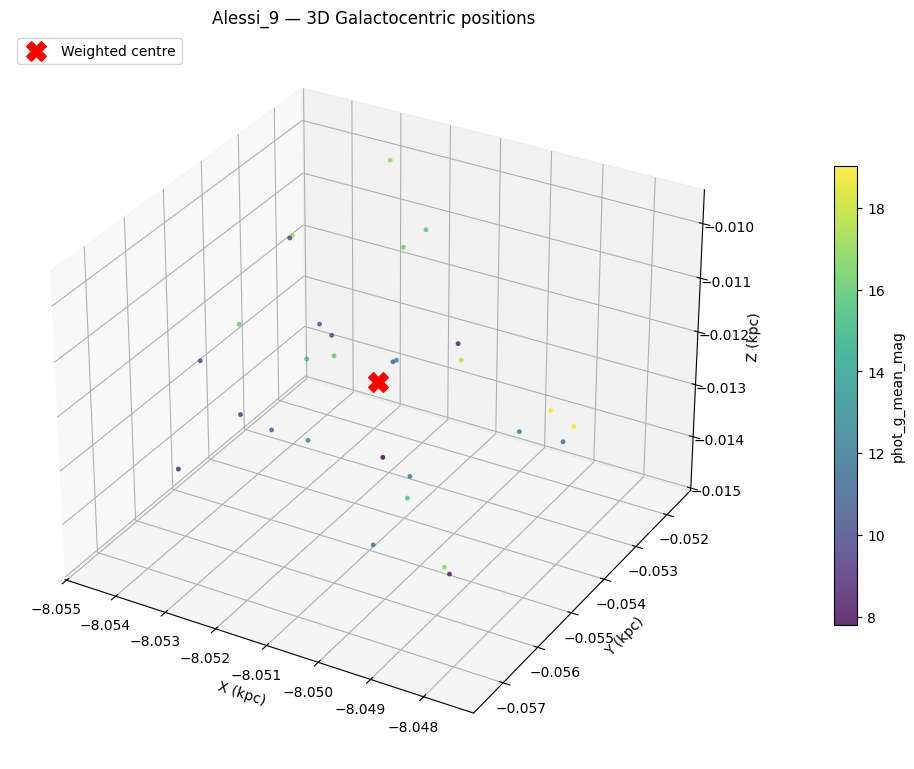

In [57]:
fig = plt.figure(figsize=(10, 8))
ax = fig.add_subplot(111, projection="3d")

sc = ax.scatter(
    df_clean["X_kpc"], df_clean["Y_kpc"], df_clean["Z_kpc"],
    c=df_clean["phot_g_mean_mag"], cmap="viridis", s=12, alpha=0.8,
    edgecolors="none"
)

# Mark the weighted centre
ax.scatter(*centre, c="red", marker="X", s=200, zorder=5, label="Weighted centre")

ax.set_xlabel("X (kpc)")
ax.set_ylabel("Y (kpc)")
ax.set_zlabel("Z (kpc)")
ax.set_title(f"{CLUSTER_NAME} — 3D Galactocentric positions")
ax.legend(loc="upper left")

cbar = fig.colorbar(sc, ax=ax, shrink=0.6, pad=0.1)
cbar.set_label("phot_g_mean_mag")

plt.tight_layout()
fig.savefig(CACHE_DIR / "melotte22_3d.png", dpi=150, bbox_inches="tight")
print(f"Saved 3D plot to {CACHE_DIR / 'melotte22_3d.png'}")
plt.show()

## Cell 9 — Visualisation: Colour–Magnitude Diagram (CMD)

The CMD plots the colour index `BP − RP` against apparent G-band magnitude
(with the y-axis inverted so that brighter stars are at the top, as is conventional).

For the Pleiades, we expect a clean main sequence extending from bright blue
stars (upper left) to faint red dwarfs (lower right).

Saved CMD to cache/melotte22_cmd.png


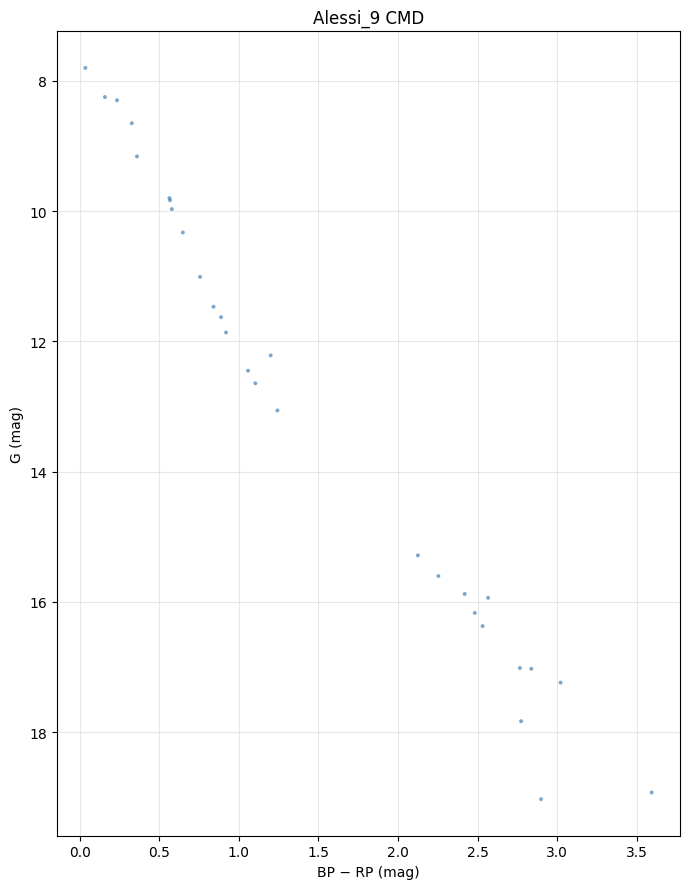

In [58]:
fig, ax = plt.subplots(figsize=(7, 9))

ax.scatter(
    df_clean["bp_rp"], df_clean["phot_g_mean_mag"],
    s=8, alpha=0.7, c="steelblue", edgecolors="none"
)

ax.invert_yaxis()  # brighter magnitudes at top
ax.set_xlabel("BP − RP (mag)")
ax.set_ylabel("G (mag)")
ax.set_title(f"{CLUSTER_NAME} CMD")
ax.grid(True, alpha=0.3)

plt.tight_layout()
fig.savefig(CACHE_DIR / "melotte22_cmd.png", dpi=150, bbox_inches="tight")
print(f"Saved CMD to {CACHE_DIR / 'melotte22_cmd.png'}")
plt.show()

## Cell 10 — Summary table and validation

We print a consolidated summary of all computed quantities and compare them
against the expected order of magnitude from **Table A.1** of the paper.

For a young, nearby cluster like Melotte 22 (~125 Myr, ~136 pc) we expect:
- D̄ᵢ  ~ 0.01–0.02 kpc
- D̄c  ~ 0.001–0.005 kpc
- D̄cc ~ 0.005–0.015 kpc

In [59]:
mean_plx = df_clean["parallax"].mean()
mean_dist = df_clean["r_med_geo"].mean()

print("=" * 65)
print(f"  SUMMARY  —  {CLUSTER_NAME} (Pleiades)")
print("=" * 65)
print(f"  N stars (after all filters)  : {len(df_clean)}")
print(f"  Mean parallax               : {mean_plx:.3f} mas")
print(f"  Mean r_med_geo              : {mean_dist:.1f} pc")
print(f"  ---")
print(f"  D̄ᵢ  (Mean Interdistance)    : {D_i:.6f} kpc")
print(f"  D̄c  (Mean Closest Interd.)   : {D_c:.6f} kpc")
print(f"  D̄cc (Med. Wtd Central Interd.): {D_cc:.6f} kpc")
print(f"  ---")
print(f"  PC1                         : {pc1:.4f}")
print(f"  PC2                         : {pc2:.4f}")
print(f"  PC3                         : {pc3:.4f}")
print("=" * 65)

# ---- Validation against paper's Table A.1 expected ranges ----
print("\n--- Validation against expected values (Table A.1) ---")

checks = [
    ("D̄ᵢ",  D_i,  0.001, 0.04),   # young clusters like Pleiades can be very compact
    ("D̄c",  D_c,  1e-6,  0.01),   # after Eq. 2 denominator fix: n(n-1)
    ("D̄cc", D_cc, 0.001, 0.03),
]

all_ok = True
for name, val, lo_exp, hi_exp in checks:
    in_range = lo_exp <= val <= hi_exp
    status = "OK" if in_range else "CHECK"
    if not in_range:
        all_ok = False
    print(f"  {name} = {val:.6f} kpc   expected [{lo_exp}, {hi_exp}]  -> {status}")

if all_ok:
    print("\nAll interdistances are within the expected order of magnitude.")
else:
    print("\nSome values are outside expected ranges — review filters and data.")

print("\nNote: exact values depend on the membership list, IQR cleaning, and")
print("Bailer-Jones distance posterior.  Small deviations from Table A.1 are expected.")

  SUMMARY  —  Alessi_9 (Pleiades)
  N stars (after all filters)  : 29
  Mean parallax               : 4.782 mas
  Mean r_med_geo              : 208.1 pc
  ---
  D̄ᵢ  (Mean Interdistance)    : 0.003875 kpc
  D̄c  (Mean Closest Interd.)   : 0.000040 kpc
  D̄cc (Med. Wtd Central Interd.): 0.002907 kpc
  ---
  PC1                         : 0.5850
  PC2                         : 0.2342
  PC3                         : 0.1808

--- Validation against expected values (Table A.1) ---
  D̄ᵢ = 0.003875 kpc   expected [0.001, 0.04]  -> OK
  D̄c = 0.000040 kpc   expected [1e-06, 0.01]  -> OK
  D̄cc = 0.002907 kpc   expected [0.001, 0.03]  -> OK

All interdistances are within the expected order of magnitude.

Note: exact values depend on the membership list, IQR cleaning, and
Bailer-Jones distance posterior.  Small deviations from Table A.1 are expected.
